# Проект. Исследование стартапов

## Введение

Поле для вашего введения: опишите контекст и цели проекта. Чтобы изменить содержимое ячейки, дважды нажмите на неё или нажмите «Ввод».

**Описание проекта**

Финансовая компания, работающая с венчурными инвестициями, хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. Для этого необходимо провести исследование на исторических данных. Необходимо будет работать с информацией о компаниях, объёмах и типах привлечённых инвестиций, а также с дополнительной статистикой по возвратам средств.

**Цель проекта**

Подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий.

**Задачи проекта**

В рамках проекта необходимо:
- Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.
- Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
- Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
- Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
- Сравнить популярность и объёмы разных типов финансирования.
- Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
- Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
- Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузите необходимые для работы библиотеки.

Совет: если вы неоднократно используете какой-либо код, вынесите его в начало проекта в виде функций.

In [1]:
#Загружаем библиотеки необходимые для работы:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install phik

In [3]:
from phik import phik_matrix

Загрузите все данные по проекту.

Совет: данные из zip-архива можно загрузить следующим кодом:

`df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)`

In [4]:
#Выгружаем данные в переменные df_investments и df_returns:
df_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
df_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

Выведите информацию, которая необходима для принятия решений о предобработке.

In [5]:
#Выведем информацию и первые строки датафрейма df_investments:
df_investments.info()
df_investments.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
#Посчитаем количество пропусков в каждых столбцах датафрейма df_investments в абсолютном и относительном значениях:
print('Абсолютное количество пропусков:')
print(df_investments.isna().sum().sort_values(ascending = False))
print('Относительное количество пропусков:')
print(df_investments.isna().mean().sort_values(ascending = False))

Абсолютное количество пропусков:
state_code              24133
mid_funding_at          24006
participants            23821
founded_month           15812
founded_quarter         15812
founded_at              15740
founded_year            15740
city                    10972
country_code            10129
region                  10129
category_list            8817
 market                  8817
homepage_url             8305
status                   6170
name                     4857
private_equity           4856
round_E                  4856
round_F                  4856
round_D                  4856
round_C                  4856
round_G                  4856
round_B                  4856
round_A                  4856
product_crowdfunding     4856
secondary_market         4856
post_ipo_debt            4856
post_ipo_equity          4856
venture                  4856
grant                    4856
angel                    4856
debt_financing           4856
convertible_note         4856
undiscl

In [7]:
df_returns.info()
df_returns.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

**Выводы о полученных данных:**

`df_investments`:
- В датафрейме содержится 40 столбцов и 54294 строки.
- В названиях некоторых столбцов присутствуют лишние пробелы, которые необходимо убрать.
- Присутствуют столбцы с некорректным типом данных. 
- В каждом столбце присутствуют пропуски, самое маленькое значение пропусков 8,9% от общего объема данных.
- Значения в столбцах соответствуют своему описанию

`df_returns`:
- В датафрейме содержится 14 столбцов и 15 строк.
- Столбцы имеют корректные названия, отражающие данные в них.
- Пропусков в столбцах нет, однако следует проверить столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
- В столбцах используется корректные типы данных

### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [8]:
#Убираем лишние пробелы в начале названия столбцов датафрейма df_investments:
df_investments.columns = df_investments.columns.str.strip()

In [9]:
#Убираем лишние пробелы перед названиями сегментов, т.к. в дальнейшем данный столбец будет часто использоваться:
df_investments['market'] = df_investments['market'].str.strip()

In [10]:
#Проверяем что метод сработал:
df_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3   market                45477 non-null  object 
 4   funding_total_usd     49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [11]:
#Для начала я считаю логичным ознакомиться с данными, т.к. тип данных Object, тут могут быть не только числа:
df_investments['funding_total_usd'].head(30)

0       9,00,00,000 
1         20,00,000 
2         90,00,000 
3         77,00,000 
4          5,40,000 
5       1,90,00,000 
6       1,20,00,000 
7         87,00,000 
8         60,00,000 
9         35,00,000 
10      2,80,00,000 
11        27,05,000 
12        89,00,000 
13              -   
14        80,00,000 
15              -   
16        39,00,000 
17     75,05,00,000 
18        20,00,000 
19              -   
20     17,50,00,000 
21        20,00,000 
22      1,53,04,039 
23      9,00,00,000 
24         1,97,634 
25      4,35,00,000 
26        50,00,000 
27              -   
28      1,34,00,000 
29        77,00,000 
Name: funding_total_usd, dtype: object

Мы видим что в данных содержаться прочерки, которые говорят нам об отсутствии данных, но также мы знаем что в столбце есть и обычные пропуски NaN.

In [12]:
#Посчитаем количество пропусков в столбце:
df_investments['funding_total_usd'].isna().sum()

4856

Отсюда мы можем сделать вывод что необходимо сначала заполнить пропуски. Я предлагаю заменить их на "0", после чего уже заменять прочерки и запятые

In [13]:
#Удалим пробелы перед прочерками:
df_investments['funding_total_usd'] = df_investments['funding_total_usd'].str.replace(' ', '')
#Заменим прочерки на NaN:
df_investments['funding_total_usd'] = df_investments['funding_total_usd'].replace('-', pd.NA)
#Уберем запятые из разрядов:
df_investments['funding_total_usd'] = df_investments['funding_total_usd'].str.replace(',', '')
#Изменим тип данных на числовой:
df_investments['funding_total_usd'] = pd.to_numeric(df_investments['funding_total_usd'])

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [14]:
#Поменяем тип данных в столбце first_funding_at:
df_investments['first_funding_at'] = pd.to_datetime(df_investments['first_funding_at'], format = '%Y-%m-%d', errors = 'coerce')

In [15]:
#Поменяем тип данных в столбцах last_funding_at:
df_investments['last_funding_at'] = pd.to_datetime(df_investments['last_funding_at'], format = '%Y-%m-%d', errors = 'coerce')

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [16]:
#Сделаем столбец year индексом датафрейма df_returns:
df_returns = df_returns.set_index('year')

Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [17]:
#Заполним пропуски в столбцах name и market, т.к. в дальнейшем они будут использоваться:
df_investments['name'] = df_investments['name'].fillna('Нет информации')

In [18]:
df_investments['market'] = df_investments['market'].fillna('Нет информации')

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [19]:
#Посчитаем количество полных дубликатов в данных датафрейма df_investments:
print('Количество полных дубликатов:')
print(df_investments.duplicated().sum())
print('Процентное соотношение дубликатов:')
print(round(df_investments.duplicated().mean()*100, 2))

Количество полных дубликатов:
4855
Процентное соотношение дубликатов:
8.94


In [20]:
#Посчитаем количество полных дубликатов в данных датафрейма df_returns:
print('Количество полных дубликатов:')
print(df_returns.duplicated().sum())

Количество полных дубликатов:
0


In [21]:
#Удалим полные дубликаты в данных датафрейма df_investments:
df_investments = df_investments.drop_duplicates()

In [22]:
#Убираем строки со значением NaN:
df_investments = df_investments.dropna(subset=['funding_total_usd']).copy()

Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [23]:
#Напишем функцию для расчета середины интервала:
def calculate_mid(row):
    if pd.isna(row['mid_funding_at']):
        if not pd.isna(row['first_funding_at']) and not pd.isna(row['last_funding_at']):
            return ((row['last_funding_at'] - row['first_funding_at'])/2) + row['first_funding_at']
    return row['mid_funding_at']

In [24]:
#Применим функцию с столбцу mid_funding_at:
df_investments['mid_funding_at'] = df_investments.apply(calculate_mid, axis=1)

In [25]:
#Посчитаем количество оставшихся пропусков:
filled_count = df_investments['mid_funding_at'].isna().sum()
print(f"Осталось пропусков: {filled_count}")
print(df_investments[['first_funding_at', 'mid_funding_at', 'last_funding_at']].head(10))

Осталось пропусков: 1
  first_funding_at mid_funding_at last_funding_at
0       2014-01-06     2014-01-06      2014-01-06
1       2014-05-15     2014-05-15      2014-05-15
2       2009-07-02     2009-07-02      2009-07-02
3       2013-11-21     2013-11-21      2014-11-03
4       2014-01-14     2014-01-14      2014-01-14
5       2014-10-23     2014-10-23      2014-10-23
6       2013-09-05     2013-09-05      2013-12-22
7       2014-01-12     2014-01-12      2014-01-12
8       2014-09-30     2014-09-30      2014-09-30
9       2007-10-01     2007-10-01      2008-03-01


Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

In [26]:
#Посчитаем процент отброшенных данных:
original_value = 54294
current_value = len(df_investments)
print(current_value)
discarded_percent = round((1 - current_value / original_value) * 100, 2)
print(f"Отброшено {discarded_percent:}% данных")

40907
Отброшено 24.66% данных


**Вывод:**
После предобработки осталось 75% от исходных данных. Считаю что такое количество достаточно для решения задач проекта.

## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [27]:
#Вычислим сроки финансирования:
df_investments['funding_days_diff'] = (df_investments['last_funding_at'] - df_investments['first_funding_at']).dt.days
#Создадим функцию для разбивки по категориям:
def categorize_funding(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif row['funding_days_diff'] <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'
#Применим функцию:
df_investments['funding_category'] = df_investments.apply(categorize_funding, axis=1)
print(df_investments['funding_category'].value_counts())

Единичное финансирование          24113
Срок финансирования более года    12293
Срок финансирования до года        4501
Name: funding_category, dtype: int64


<AxesSubplot:title={'center':'Процент компаний по срокам финансирования'}, ylabel='funding_category'>

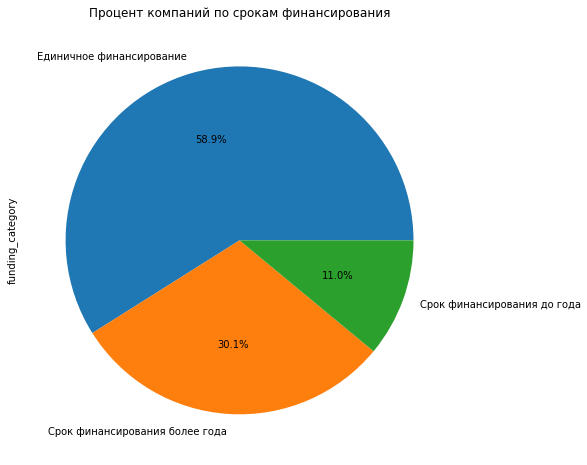

In [28]:
#Визуализируем какой процент от общего числа компаний относится к каждой из трёх групп с помощью круговой диаграммы:
df_investments['funding_category'].value_counts().plot(kind='pie',
                                autopct='%1.1f%%',
                                title='Процент компаний по срокам финансирования',
                                figsize=(8, 8),
                                labels=['Единичное финансирование', 'Срок финансирования более года', 'Срок финансирования до года'])

In [29]:
#Узнаем какой объём привлечённых средств получила каждая группа:
df_investments.groupby('funding_category')['funding_total_usd'].sum()

funding_category
Единичное финансирование          1.993044e+11
Срок финансирования более года    4.027433e+11
Срок финансирования до года       4.888598e+10
Name: funding_total_usd, dtype: float64

<AxesSubplot:title={'center':'Объем финансирования по срокам'}, ylabel='funding_total_usd'>

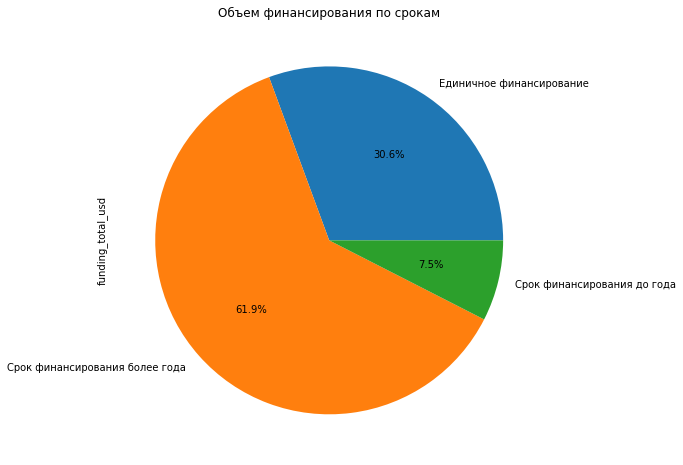

In [30]:
#Визуализируем объём привлечённых средств, которые получила каждая группа, с помощью круговой диаграммы:
df_investments.groupby('funding_category')['funding_total_usd'].sum().plot(kind='pie',
                                autopct='%1.1f%%',
                                title='Объем финансирования по срокам',
                                figsize=(8, 8),
                                labels=['Единичное финансирование', 'Срок финансирования более года', 'Срок финансирования до года'])

**Промежуточный вывод:**
На основе анализа мы видим что 58,9% компаний занимались единичным финансированием. При этом самый большой объем финансирования получает категории со сроком финансирования более года - 61,9% от общего объема. То есть мы можем наблюдать, что 30,1% от всех компаний занимаются финансированием более года и вносят туда 61,9% от всего объема финансирования.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

In [31]:
#Отфильтруем значения столбца market и уберем оттуда значения "Нет информации":
df_2_2 = df_investments[df_investments['market'] != 'Нет информации']
#Посчитаем количество компаний в каждом сегменте:
market_counts = df_2_2.groupby('market')['name'].count().reset_index(name = 'company_count')
#Создадим функцию для распределения по категориям:
def market_segment(count):
    if count > 120:
        return 'Массовый сегмент'
    elif count >= 35:
        return 'Средний сегмент'
    else:
        return 'Нишевый сегмент'
#Применим функцию:
market_counts['market_segment'] = market_counts['company_count'].apply(market_segment)
#Посчитаем количество сегментов в каждой категории:
segment_distribution = market_counts['market_segment'].value_counts()
print("Количество сегментов в каждой категории:")
print(segment_distribution)

Количество сегментов в каждой категории:
Нишевый сегмент     289
Средний сегмент      57
Массовый сегмент     48
Name: market_segment, dtype: int64


In [32]:
#Отфильтруем датафрейм оставив только информацию о нишевом и среднем сегменте:
filtered_counts = market_counts[market_counts['market_segment'].isin(['Нишевый сегмент', 'Средний сегмент'])]

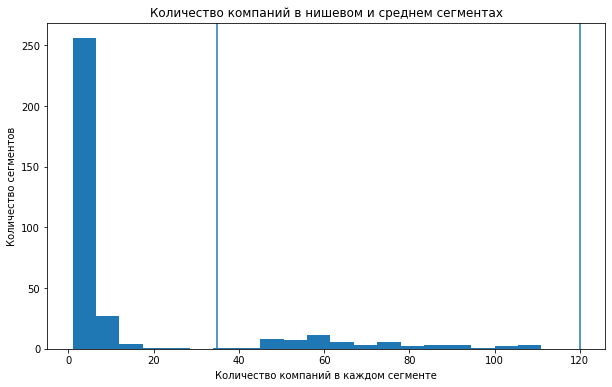

In [33]:
#Построим гистограмму:
plt.figure(figsize = (10, 6))
plt.hist(filtered_counts['company_count'], bins = 20)
plt.axvline(35)
plt.axvline(120)
plt.xlabel('Количество компаний в каждом сегменте')
plt.ylabel('Количество сегментов')
plt.title('Количество компаний в нишевом и среднем сегментах')
plt.show()

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [34]:
#Создадим список массовых сегментов:
massive_segments = []
for market_name in df_2_2['market'].unique():
    count = df_2_2[df_2_2['market'] == market_name].shape[0]
    if count > 120:
        massive_segments.append(market_name)

#Создадим функцию, чтобы заменить значения в столбце market:
def replace_segment(market_name):
    if market_name == 'Нет информации':
        return market_name
    elif market_name in massive_segments:
        return market_name
    elif df_2_2[df_2_2['market'] == market_name].shape[0] >= 35:
        return 'mid'
    else:
        return 'niche'

#Применим функцию:
df_investments['market'] = df_investments['market'].apply(replace_segment)

**Промежуточный вывод:**
Исходя из расчетов выше мы видим что большинство сегментов относятся к нисшевым - 289 компаний из 394. Меньше всего коммпаний относятся к массовому сегменту - всего 48 компаний.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

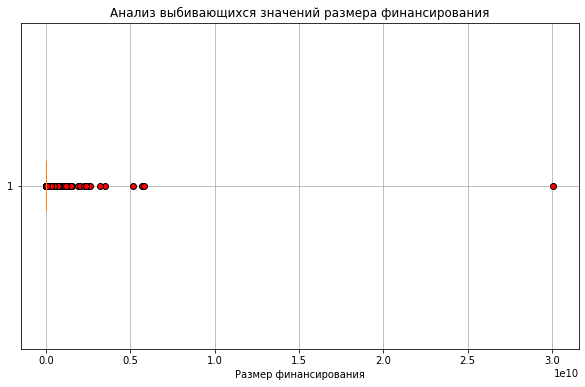

In [67]:
#Построим диаграмму размаха:
plt.figure(figsize = (10, 6))
plt.boxplot(df_investments['funding_total_usd'], vert = False, flierprops = dict(markerfacecolor = 'red', marker = 'o'))
plt.title('Анализ выбивающихся значений размера финансирования')
plt.xlabel('Размер финансирования')
plt.grid(True)

In [36]:
#Посмотрим статистические данные столбца funding_total_usd:
df_investments['funding_total_usd'].describe()

count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

**Промежуточный вывод:**
На основе анализа данных мы можем видеть следующее:
- Типичный (медианный) размер финансирования компании составляет 2 млн.
- Интервал типичных значений (в который попадает 50% центральных наблюдений) составляет от 350 тыс. до 10 млн.

Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [37]:
#Посчитаем количество выбросов для каждого сегмента:
results = []

for segment in df_investments['market'].unique():
    data = df_investments[df_investments['market'] == segment]['funding_total_usd']    
    if len(data) > 0:
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = data[(data < lower) | (data > upper)]
        outlier_count = len(outliers)
        total_count = len(data)
        
#Посчитаем долю выбросов:
        if total_count > 0:
            percentage = round((outlier_count / total_count) * 100, 2)
        else:
            percentage = 0
            
        results.append({
            'segment': segment,
            'total': total_count,
            'outliers': outlier_count,
            'percentage': percentage
        })

#Создадим датафрейм с результатами:
results_df = pd.DataFrame(results)

#Отсортируем полученные значения:
top_segments = results_df.sort_values('percentage', ascending=False)

print("Топ сегментов по доле аномального финансирования:")
print(top_segments.head(10))

Топ сегментов по доле аномального финансирования:
            segment  total  outliers  percentage
30      Real Estate    279        48       17.20
44    Entertainment    150        25       16.67
29       Consulting    349        58       16.62
40           Search    291        48       16.49
46  Cloud Computing    152        25       16.45
38      Photography    204        33       16.18
45             SaaS    272        44       16.18
31       Technology    238        38       15.97
42            Video    188        30       15.96
11            niche    830       132       15.90


**Промежуточный вывод:**
Как мы можем видеть из данных выше, сегментом рынка с наибольшей долей компаний, получивших аномальное финансирование является "Real Estate". Из 279 компании, 48 получили аномальное финансирование, что составляет 17,20%.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [38]:
#Посмотрим какие крайние даты за 2014 год содержит датафрейм:
print("Первая дата финансирования в 2014 г:", df_investments['first_funding_at'][df_investments['first_funding_at'].dt.year == 2014].min())
print("Последняя дата финансирования в 2014 г:", df_investments['first_funding_at'][df_investments['first_funding_at'].dt.year == 2014].max())

#Посмотрим количество первых и последних финансирований за последние 4 года:
print("\nРаспределение по годам первого финансирования:")
print(df_investments['first_funding_at'][df_investments['first_funding_at'].dt.year > 2010].dt.year.value_counts().sort_index())
print("\nРаспределение по годам последнего финансирования:")
print(df_investments['last_funding_at'][df_investments['last_funding_at'].dt.year > 2010].dt.year.value_counts().sort_index())

print('')

#Посмотрим сколько компаний получило первое финансирование в 2014 году.
first_funding_2014 = df_investments[df_investments['first_funding_at'].dt.year == 2014]
print(f"Компаний с первым финансированием в 2014: {len(first_funding_2014)}")

#Посмотрим сколько компаний получило последнее финансирование в 2014 году.
last_funding_2014 = df_investments[df_investments['last_funding_at'].dt.year == 2014]
print(f"Компаний с последним финансированием в 2014: {len(last_funding_2014)}")

Первая дата финансирования в 2014 г: 2014-01-01 00:00:00
Последняя дата финансирования в 2014 г: 2014-12-31 00:00:00

Распределение по годам первого финансирования:
2011    4964
2012    5748
2013    7176
2014    6477
Name: first_funding_at, dtype: int64

Распределение по годам последнего финансирования:
2011     4109
2012     5296
2013     8687
2014    11915
Name: last_funding_at, dtype: int64

Компаний с первым финансированием в 2014: 6477
Компаний с последним финансированием в 2014: 11915


**Промежуточный вывод:**
Исходя из информации выше я могу сделать вывод о том, что данных за 2014 год достаточно для дальнейшего анализа.

In [39]:
#Создадим цикл чтобы исключить из датасета компании, которые мы ранее посчитали получившими аномальное финансирование:
anomalous_companies = []


for segment in df_investments['market'].unique():
    segment_data = df_investments[df_investments['market'] == segment]['funding_total_usd']   
    if len(segment_data) > 5:
        Q1 = segment_data.quantile(0.25)
        Q3 = segment_data.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        segment_indices = df_investments[df_investments['market'] == segment].index
        segment_values = df_investments.loc[segment_indices, 'funding_total_usd']
        
        anomalous_mask = (segment_values < lower_bound) | (segment_values > upper_bound)
        anomalous_indices = segment_indices[anomalous_mask]
        
        anomalous_companies.extend(anomalous_indices.tolist())

#Преобразуем в множество:
anomalous_companies = set(anomalous_companies)

#Создадим новый датафрейм без аномальных компаний:
df_clean = df_investments[~df_investments.index.isin(anomalous_companies)].copy()

In [40]:
#Создадим новый столбец в котором будут указаны годы:
df_clean['funding_year'] = df_clean['mid_funding_at'].dt.year

In [41]:
#Сгруппируем данные по новому столбцу и посчитаем количество раундов в каждом году:
df_clean.groupby('funding_year')['funding_rounds'].sum()

funding_year
1921.0        1.0
1960.0        2.0
1979.0        1.0
1982.0        3.0
1983.0        1.0
1984.0        2.0
1985.0        3.0
1987.0        2.0
1989.0        1.0
1990.0        1.0
1992.0        5.0
1993.0        1.0
1994.0        4.0
1995.0        9.0
1996.0        8.0
1997.0        5.0
1998.0       15.0
1999.0       43.0
2000.0      113.0
2001.0       66.0
2002.0       98.0
2003.0      125.0
2004.0      181.0
2005.0      948.0
2006.0     1849.0
2007.0     2842.0
2008.0     3663.0
2009.0     4617.0
2010.0     6136.0
2011.0     7578.0
2012.0     9707.0
2013.0    12880.0
2014.0     7122.0
Name: funding_rounds, dtype: float64

**Промежуточный вывод:**
Как мы видим из данных выше, начиная с 2000 года в каждом году было более 50 раундов, значит эти данные мы и оставим.

In [42]:
#Сохраним новый датафрейм:
df_actual = df_clean[df_clean['funding_year'] >= 2000].copy()

### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [43]:
#Посчитаем общую сумму финансирования по каждому типу:
funding_sums = df_actual[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                          'convertible_note', 'debt_financing', 'angel', 'grant', 
                          'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                          'secondary_market', 'product_crowdfunding']].sum().sort_values(ascending = False)
print(funding_sums)

venture                 1.290922e+11
seed                    9.431332e+09
debt_financing          8.178153e+09
private_equity          4.843109e+09
angel                   2.481264e+09
undisclosed             2.100352e+09
grant                   1.978849e+09
post_ipo_equity         1.946452e+09
convertible_note        5.660394e+08
post_ipo_debt           2.867183e+08
equity_crowdfunding     2.379606e+08
product_crowdfunding    1.860939e+08
secondary_market        4.528580e+07
dtype: float64


<AxesSubplot:title={'center':'Объем финансирования по видам'}, ylabel='Виды финансирования'>

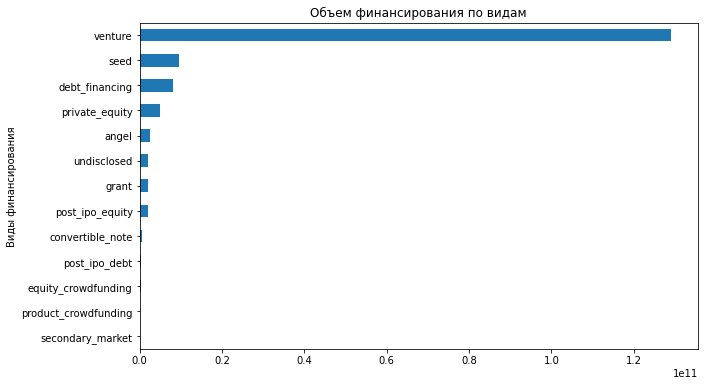

In [44]:
#Построим горизонтальную столбчатую диаграму для наглядного отображения результатов:
funding_sums.sort_values().plot(kind = 'barh',
                  title = 'Объем финансирования по видам',
                  legend = False,
                  ylabel = 'Сумма привлеченных денежных средств',
                  xlabel = 'Виды финансирования',
                  rot = 0,
                  figsize = (10, 6))

In [45]:
#Посчитаем количество раз, когда компании выбирали тот или иной тип финансирования:
funding_counts = (df_actual[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                             'convertible_note', 'debt_financing', 'angel', 'grant', 
                             'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                             'secondary_market', 'product_crowdfunding']] > 0).sum().sort_values(ascending = False)
print(funding_counts)

venture                 18820
seed                    13375
debt_financing           3265
angel                    2937
grant                    1003
undisclosed               813
private_equity            634
convertible_note          521
equity_crowdfunding       515
product_crowdfunding      204
post_ipo_equity           164
post_ipo_debt              27
secondary_market            7
dtype: int64


<AxesSubplot:title={'center':'Популярность видов финансирования'}, ylabel='Виды финансирования'>

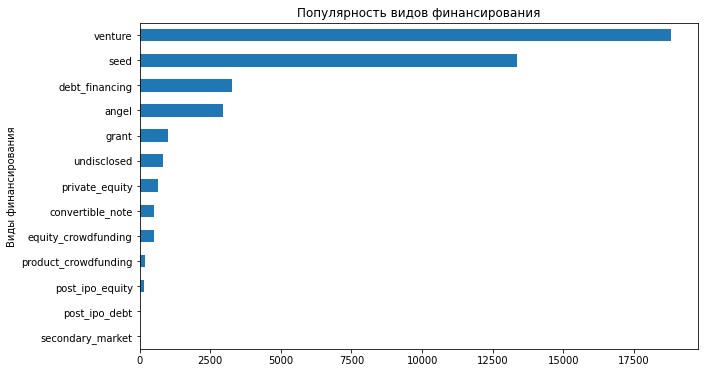

In [46]:
#Построим еще одну горизонтальную столбчатую диаграму для наглядного отображения результатов:
funding_counts.sort_values().plot(kind = 'barh',
                  title = 'Популярность видов финансирования',
                  legend = False,
                  ylabel = 'Сумма привлеченных денежных средств',
                  xlabel = 'Виды финансирования',
                  rot = 0,
                  figsize = (10, 6))

**Промежуточный вывод:**
Среди часто используемых типов финансирования, которые при этом характеризуются небольшими объёмами можно выделить `seed`, `angel` и `grant`.
Те типы финансирования, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм, четко выделить, на мой взгляд, невозможно, т.к. они распределены равномерно.

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [47]:
#Посчитаем объем возвратов по каждому типу финансирования:
refunding_sums = df_returns[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 
                             'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market',
                             'product_crowdfunding']].sum().sort_values(ascending = False)
print(refunding_sums)

venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64


<AxesSubplot:title={'center':'Популярность видов финансирования'}, ylabel='Виды финансирования'>

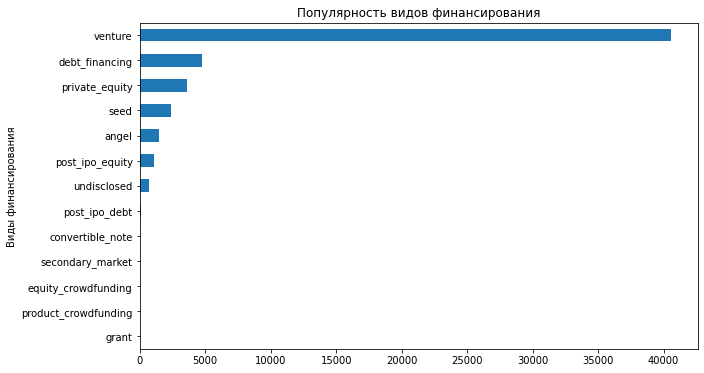

In [48]:
#Построим горизонтальную столбчатую диаграму для наглядного отображения результатов:
refunding_sums.sort_values().plot(kind = 'barh',
                  title = 'Популярность видов финансирования',
                  legend = False,
                  ylabel = 'Сумма привлеченных денежных средств',
                  xlabel = 'Виды финансирования',
                  rot = 0,
                  figsize = (10, 6))

**Промежуточный вывод:**
Как мы можем видеть, большинство возвратов приходит от типа финансирования `venture`

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [49]:
#Добавим столбец avg_round в котором будет рассчитан средний объём одного раунда финансирования:
df_actual['avg_round'] = df_actual['funding_total_usd']/df_actual['funding_rounds']
print(df_actual['avg_round'])

1        2.000000e+06
2        9.000000e+06
3        2.566667e+06
4        5.400000e+05
7        8.700000e+06
             ...     
49430    1.500000e+06
49433    1.500000e+06
49434    9.000000e+06
49435    2.500000e+05
49437    1.150000e+04
Name: avg_round, Length: 35588, dtype: float64


In [50]:
#Посчитаем типичный размер средств, которые стартапы получали в рамках одного раунда финансирования:
avg_year = df_actual.groupby('funding_year')['avg_round'].mean().reset_index()
print(avg_year)

    funding_year     avg_round
0         2000.0  4.492723e+06
1         2001.0  3.366817e+06
2         2002.0  4.053461e+06
3         2003.0  3.099490e+06
4         2004.0  4.616702e+06
5         2005.0  5.801089e+06
6         2006.0  5.346925e+06
7         2007.0  4.678782e+06
8         2008.0  4.322739e+06
9         2009.0  3.517328e+06
10        2010.0  3.188317e+06
11        2011.0  2.598416e+06
12        2012.0  2.035770e+06
13        2013.0  1.976610e+06
14        2014.0  2.203065e+06


Text(0, 0.5, 'Объемы финансирования')

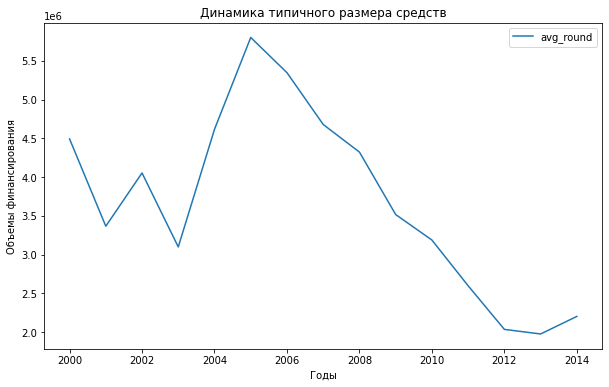

In [51]:
#Построим линейный график:
avg_year.plot.line(x = 'funding_year',
                   y = 'avg_round',
                   title = 'Динамика типичного размера средств',
                   figsize = (10, 6))
plt.xlabel('Годы')
plt.ylabel('Объемы финансирования')

In [52]:
#Посчитаем количество раундов за каждый год:
round_year = df_actual.groupby('funding_year')['funding_rounds'].sum().reset_index()
print(round_year)

    funding_year  funding_rounds
0         2000.0           113.0
1         2001.0            66.0
2         2002.0            98.0
3         2003.0           125.0
4         2004.0           181.0
5         2005.0           948.0
6         2006.0          1849.0
7         2007.0          2842.0
8         2008.0          3663.0
9         2009.0          4617.0
10        2010.0          6136.0
11        2011.0          7578.0
12        2012.0          9707.0
13        2013.0         12880.0
14        2014.0          7122.0


Text(0, 0.5, 'Количество раундов')

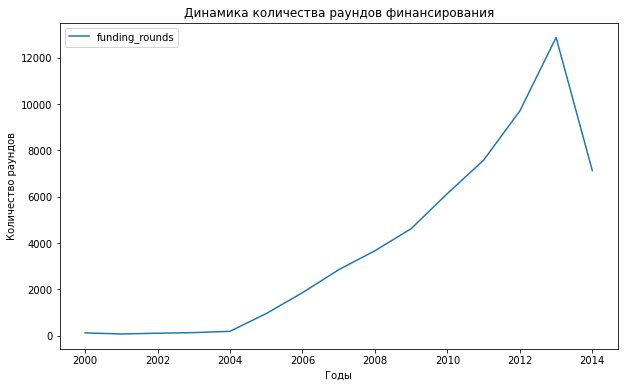

In [53]:
#Построим еще один линейный график:
round_year.plot.line(x = 'funding_year',
                     y = 'funding_rounds',
                     title = 'Динамика количества раундов финансирования',
                     figsize = (10, 6))
plt.xlabel('Годы')
plt.ylabel('Количество раундов')

**Промежуточный вывод:**
Как мы можем видеть из расчетов выше, типичный размер средств, которые стартапы получали в рамках одного раунда финансирования вел себя непредсказуемо до 2005 года. В 2005 году он показал самое высокое значение, после чего ежегодно уменьшался вплоть до 2013 года. В 2014 году размер средств вырос.

Количество раундов финансирования, в отличие от размера средств, находился, примерно, на одном уровне в период с 2000 по 2004 год, после чего начался уверенный ежегодный рост, но, достигнув пика в 2013 году на значении 12880 раундов, в 2014 году резко уменьшился до 7122 раундов.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [54]:
#Отфильтруем столбец market и уберем строки где нет информации:
df_4_2 = df_actual[df_actual['market'] != 'Нет информации']
#Создадим сводную таблицу:
svod = pd.pivot_table(df_4_2, 
                      index = 'market',
                      columns = 'funding_year',
                      values = 'funding_total_usd',
                      aggfunc = 'sum')

In [55]:
#Создадим столбец сводной таблицы, где посчитаем разницу между 2014 и 2013 годами:
svod['growth_2013_2014'] = svod[2014] - svod[2013]
#Создадим столбец сводной таблицы, где посчитаем разницу в процентном соотношении:
svod['growth_percent'] = round((svod[2014] - svod[2013]) / svod[2013] * 100, 2)
#Выберем значения где есть положительная разница:
growing_segments = svod[svod['growth_2013_2014'] > 0].copy()
growing_segments = growing_segments.sort_values('growth_2013_2014', ascending=False)
print(growing_segments[[2013, 2014, 'growth_2013_2014', 'growth_percent']])
print(growing_segments)

funding_year         2013.0        2014.0  growth_2013_2014  growth_percent
market                                                                     
niche          2.699043e+08  7.381729e+08       468268633.0          173.49
mid            1.686905e+09  1.868755e+09       181850325.0           10.78
Medical        6.446942e+07  1.752361e+08       110766640.0          171.81
Technology     1.208739e+08  2.020189e+08        81145050.0           67.13
Internet       6.973210e+07  1.178308e+08        48098660.0           68.98
Apps           2.886862e+07  6.623773e+07        37369109.0          129.45
Startups       1.808055e+07  4.150184e+07        23421285.0          129.54
Real Estate    9.220766e+07  1.155674e+08        23359709.0           25.33
Manufacturing  3.939366e+08  4.163323e+08        22395680.0            5.69
SaaS           7.957661e+07  9.280775e+07        13231139.0           16.63
Design         6.095884e+07  6.898852e+07         8029681.0           13.17
Big Data    

In [56]:
#Отфильтруем датафрейм по категориям, которые показывали положительную динамику и возьмем данные, начиная с 2008 года,т.к. начиная с этого года они являются полными:
growing_markets = ['Medical', 'Technology', 'Internet', 'Apps', 'Startups', 'Real Estate', 'Manufacturing', 'SaaS', 
                   'Design', 'Big Data']
df_4_2_filtered = df_4_2[(df_4_2['market'].isin(growing_markets)) & (df_4_2['funding_year'] >= 2008)].copy()
df_grouped = df_4_2_filtered.groupby(['funding_year', 'market'])['funding_total_usd'].sum().reset_index()
print(df_grouped)

    funding_year         market  funding_total_usd
0         2008.0           Apps          4300000.0
1         2008.0       Big Data          2452515.0
2         2008.0         Design          5944302.0
3         2008.0       Internet         23412964.0
4         2008.0  Manufacturing        173054260.0
..           ...            ...                ...
65        2014.0        Medical        175236064.0
66        2014.0    Real Estate        115567364.0
67        2014.0           SaaS         92807752.0
68        2014.0       Startups         41501837.0
69        2014.0     Technology        202018937.0

[70 rows x 3 columns]


In [57]:
#Создадим сводную таблицу для построения дальнейшего линейного графика:
pivot_funding = pd.pivot_table(df_4_2_filtered,
                               index='funding_year',
                               columns='market',
                               values='funding_total_usd',
                               aggfunc='sum')

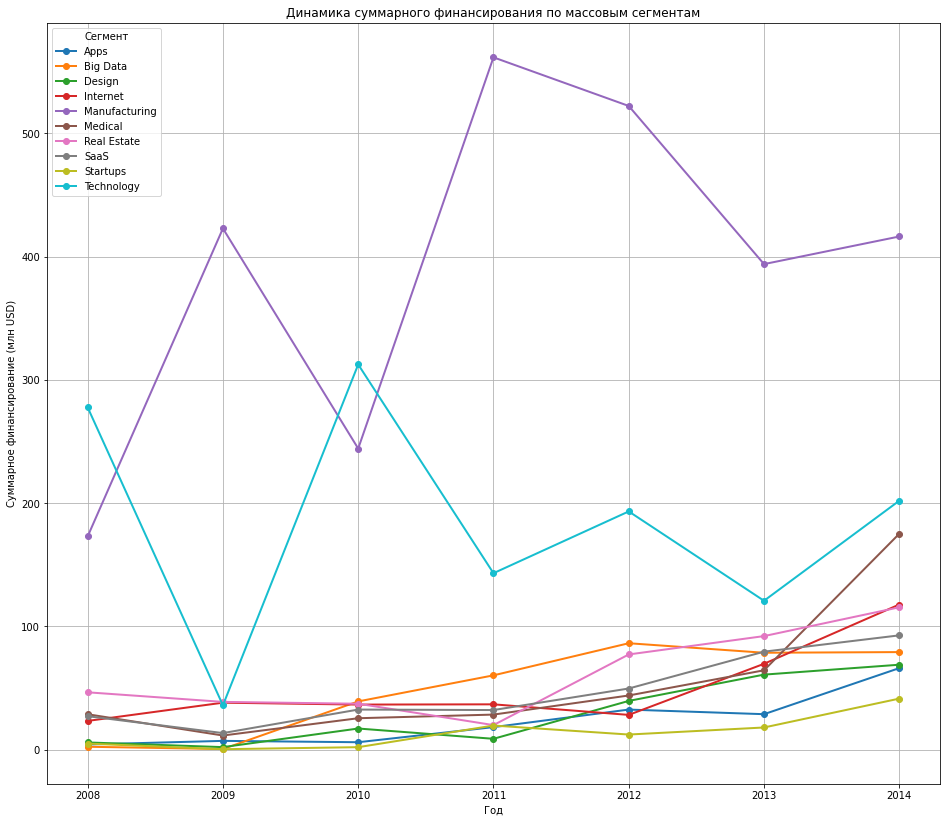

In [58]:
#Построим линейный график для каждой категории:
plt.figure(figsize=(16, 14))
for market in pivot_funding.columns:
    plt.plot(pivot_funding.index,
             pivot_funding[market] / 1e6,
             marker='o',
             linewidth=2,
             label=market)

plt.title('Динамика суммарного финансирования по массовым сегментам')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование (млн USD)')
plt.grid(True)
plt.legend(title='Сегмент', loc='upper left')

**Промежуточный вывод:**
На основе анализа выше можно сказать что сегменты `Real Estate`, `Apps`, `Startup` и `Medical` показывают уверенный и быстрый рост

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [59]:
#Соберем столбцы, где хранится информация о суммах инвестиций:
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                 'convertible_note', 'debt_financing', 'angel', 'grant', 
                 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                 'secondary_market', 'product_crowdfunding']

In [60]:
#Посчитаем сумму инвестиций по каждому году и каждому виду финансирования:
df_funding = df_actual.groupby('funding_year')[funding_types].sum()

In [61]:
#Чтобы не было ошибки при расчетах переименуем столбец year в датафрейме df_returns:
df_returns_prep = df_returns.rename(columns={'year': 'funding_year'})

In [62]:
#Посчитаем нормированные значения возврата средств:
df_result = df_returns_prep * 1000000 / (df_funding + 1e-60)

In [63]:
#Создадим функцию для замены аномальных значений:
def replace_outliers_robust(df, threshold=100):
    df_clean = df.copy()
    df_clean[df_clean > threshold] = pd.NA
    
    return df_clean

df_normalized_clean = replace_outliers_robust(df_result, threshold=100)
print("После удаления значений > 100%:")
print(df_normalized_clean)

После удаления значений > 100%:
          seed   venture  equity_crowdfunding  undisclosed  convertible_note  \
year                                                                           
2000  0.996471  0.168922             0.000000     0.697042          0.000000   
2001  1.079592  0.107991             0.000000     0.587483          0.006667   
2002  0.629707  0.682282             0.000000     0.608878               NaN   
2003  0.505276  0.628260             0.000000     0.914397               NaN   
2004  0.548476  0.837009             0.000000     0.527559               NaN   
2005  0.674695  0.546586             0.000000     1.071992               NaN   
2006  0.925372  0.343678             0.203632     0.759438          0.166318   
2007  0.366153  0.297243                  NaN     0.504971          0.228097   
2008  0.297083  0.190873                  NaN     0.342060          0.059788   
2009  0.563423  0.169517             0.087819     0.376177          0.054535   
2010  0.

Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

In [64]:
#Отфильтруем данные по заданным типам финансирования:
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
df_selected = df_normalized_clean[selected_types].copy()

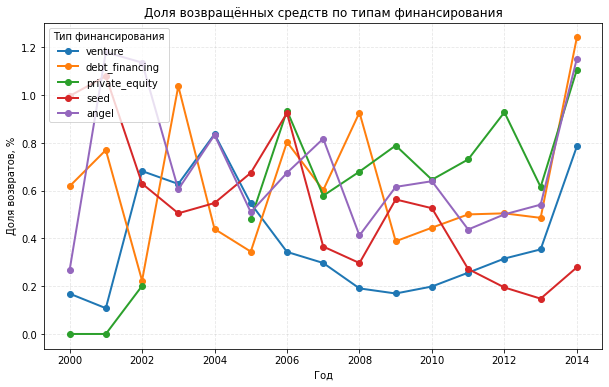

In [65]:
#Построим линейный график для каждого типа финансирования:
plt.figure(figsize=(10, 6))
for funding_type in selected_types:
    plt.plot(df_selected.index, 
             df_selected[funding_type], 
             marker='o', 
             linewidth=2,
             markersize=6,
             label=funding_type)

plt.title('Доля возвращённых средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возвратов, %')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title='Тип финансирования')

**Промежуточный вывод:**
На основе данных выше можно сказать что типы финансирования `venture` и `debt_financing` показывают наиболее устойчивый рост показателя, т.к. за последние 5 лет их значения резко не уменьшались и показывали рост.


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



**Вывод**

**Рекомендации заказчику (по состоянию на 2015 год):**

На основе проведённого анализа данных о стартапах и возвратах по инвестициям за период до 2014 года рекомендуется:

1. В какую отрасль стоит инвестировать:
Наиболее перспективными для инвестирования являются сегменты `Medical` (Медицина), `Real Estate` (Недвижимость), `Apps` (Мобильные приложения) и `Startups` (Стартапы). Эти сегменты показали значительный рост объёма финансирования в 2014 году по сравнению с 2013 годом, а также демонстрируют устойчивую положительную динамику в течение нескольких лет. Особенно выделяется сегмент `Medical`, где объём финансирования вырос на **171,81%** за один год.

2. Какой тип финансирования будет наиболее уместным:
Наиболее стабильным и растущим типом финансирования является `venture` (венчурное финансирование), которое не только привлекает наибольшие объёмы средств, но и демонстрирует устойчивый рост доли возвращённых средств. 
Также стоит рассмотреть `debt_financing` (долговое финансирование), которое показывает высокую норму возврата и стабильный рост.

**Итоги проекта:**

**Шаги:**

1. Загрузка и предобработка данных:

- Проведена очистка данных, удалены дубликаты, обработаны пропуски.

- Приведены типы данных, обработаны текстовые поля, удалены аномалии.

- Данные за 2014 год признаны полными и репрезентативными.

2. Инжиниринг признаков:

- Компании разделены на группы по срокам финансирования.

- Рынки классифицированы на массовые, средние и нишевые.

- Проведена визуализация распределения компаний и объёмов финансирования.

3. Работа с выбросами и анализ:

- Выявлены и исключены аномальные значения финансирования.

- Проанализированы типы финансирования по объёму и популярности.
 
- Построены графики возвратов по типам финансирования.

4. Анализ динамики:

- Изучена динамика среднего размера раунда и количества раундов по годам.

- Выявлены растущие сегменты рынка.

- Проанализирована доля возвращённых средств по типам финансирования.

**Ключевые выводы:**

1. Большинство стартапов (**59%**) привлекают финансирование единоразово, но основной объём средств (**62%**) получают компании, финансирующиеся более года.

2. Венчурное финансирование (venture) доминирует как по объёмам, так и по популярности.

3. Наиболее быстрорастущие сегменты: `Medical`, `Real Estate`, `Apps`, `Startups`.

4. Возвраты средств наиболее стабильны у `venture` и `debt_financing`.

5. 2014 год стал переломным: количество раундов снизилось, но средний размер раунда вырос.

**Согласованность выводов:**
Выводы в целом согласуются: сегменты, показывающие рост, также характеризуются высокой активностью инвестиций и стабильными возвратами.